In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# 图表中文显示设置
plt.rcParams['font.sans-serif'] = ['STHeiti']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据集

In [2]:
user = pd.read_parquet('data/parquet/user.parquet')
item = pd.read_parquet('data/parquet/item_data_cleaned.parquet')
click = pd.read_parquet('data/parquet/user_click.parquet')
order = pd.read_parquet('data/parquet/user_order.parquet')

In [3]:
# 1. 时间格式转换与 ID 类型统一
for df in [user, item, click, order]:
    if 'user_id' in df.columns:
        df['user_id'] = df['user_id'].astype(str)
    if 'item_id' in df.columns:
        df['item_id'] = df['item_id'].astype(str)

for df, col in [(click, 'datetime'), (click, 'dt'), (order, 'datetime'), (order, 'dt')]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].str.replace(r':$', '', regex=True)
        df[col] = pd.to_datetime(df[col], format='mixed', errors='coerce')

print(f"click datetime null: {click['datetime'].isna().sum()} / {len(click)}")
print(f"order datetime null: {order['datetime'].isna().sum()} / {len(order)}")

if order['datetime'].isna().any():
    bad_order_dates = order.loc[order['datetime'].isna(), 'datetime'].head(10)
    print('order datetime parse failed example:', bad_order_dates.tolist())

# 获取数据集的最新时间作为计算 R (Recency) 的基准日
ref_date = max(click['datetime'].max(), order['datetime'].max())
print(f"数据观测基准日: {ref_date}")

# 2. 异常点击用户过滤 (防爬虫/防刷单)
user_click_counts = click.groupby('user_id').size()
click_threshold = user_click_counts.quantile(0.999)
normal_users = user_click_counts[user_click_counts <= click_threshold].index

print(f"点击量阈值 (99.9%): {click_threshold:.0f}")
print(f"过滤前点击数据量: {len(click)}，用户数: {click['user_id'].nunique()}")

click_filtered = click[click['user_id'].isin(normal_users)].copy()
print(f"过滤后点击数据量: {len(click_filtered)}，正常用户数: {len(normal_users)}")

click datetime null: 0 / 52983323
order datetime null: 0 / 1458498
数据观测基准日: 2019-02-18 23:59:01
点击量阈值 (99.9%): 14043
过滤前点击数据量: 52983323，用户数: 85177
过滤后点击数据量: 51133681，正常用户数: 85091


In [4]:
# -------------------- A. 构建订单特征 --------------------
order_item = order.merge(
    item[['item_id', 'price', 'cid1', 'cid2', 'cid3', 'brand_code']],
    on='item_id',
    how='left'
)
order_item['price'] = order_item['price'].fillna(0)
order_item['total_amount'] = order_item['count'] * order_item['price']

order_summary = order_item.groupby('user_id').agg(
    F_count=('count', 'sum'),
    order_count=('datetime', 'nunique'),
    unique_order_items=('item_id', 'nunique'),
    total_order_amount=('total_amount', 'sum'),
    first_order_date=('datetime', 'min'),
    last_order_date=('datetime', 'max')
).reset_index()

order_summary['avg_order_amount'] = order_summary['total_order_amount'] / order_summary['order_count'].replace({0: 1})
order_summary['avg_item_price'] = order_summary['total_order_amount'] / order_summary['F_count'].replace({0: 1})
order_summary['order_span_days'] = (order_summary['last_order_date'] - order_summary['first_order_date']).dt.days
order_summary['avg_items_per_order'] = order_summary['F_count'] / order_summary['order_count'].replace({0: 1})
order_summary['repeat_item_ratio'] = 1 - order_summary['unique_order_items'] / order_summary['F_count'].replace({0: 1})
order_summary['R_days'] = (ref_date - order_summary['last_order_date']).dt.days
order_summary['days_since_first_order'] = (ref_date - order_summary['first_order_date']).dt.days
order_summary['days_since_last_order'] = order_summary['R_days']
order_summary = order_summary.drop(columns=['first_order_date', 'last_order_date'])

order_interval = (
    order.sort_values(['user_id', 'datetime'])
    .groupby('user_id')['datetime']
    .diff()
    .dt.days
    .groupby(order['user_id'])
    .mean()
    .rename('avg_order_interval_days')
    .reset_index()
)
order_features = order_summary.merge(order_interval, on='user_id', how='left')
order_features['avg_order_interval_days'] = order_features['avg_order_interval_days'].fillna(order_features['order_span_days'])

# -------------------- B. 构建 Click 行为特征 --------------------
click_item = click_filtered.merge(
    item[['item_id', 'cid1', 'cid2', 'cid3', 'brand_code']],
    on='item_id',
    how='left'
)

click_features = click_item.groupby('user_id').agg(
    total_clicks=('item_id', 'count'),
    unique_clicked_items=('item_id', 'nunique'),
    unique_cid1_clicked=('cid1', 'nunique'),
    unique_cid2_clicked=('cid2', 'nunique'),
    unique_brands_clicked=('brand_code', 'nunique'),
    first_click_date=('datetime', 'min'),
    last_click_date=('datetime', 'max')
).reset_index()

click_features['click_span_days'] = (click_features['last_click_date'] - click_features['first_click_date']).dt.days
click_features['avg_clicks_per_day'] = click_features['total_clicks'] / (click_features['click_span_days'].replace({0: 1}) + 1)
click_features['click_to_item_ratio'] = click_features['total_clicks'] / click_features['unique_clicked_items'].replace({0: 1})
click_features['last_click_days'] = (ref_date - click_features['last_click_date']).dt.days
click_features['first_click_days'] = (ref_date - click_features['first_click_date']).dt.days
click_features = click_features.drop(columns=['first_click_date', 'last_click_date'])

print("订单与行为特征提取完毕！")

订单与行为特征提取完毕！


In [5]:
# 1. 基础合并
user_features = user.merge(order_features, on='user_id', how='left')
user_features = user_features.merge(click_features, on='user_id', how='left')

# 2. 缺失值填补与逻辑衍生
max_days = (ref_date - click_filtered['datetime'].min()).days + 1
user_features['R_days'] = user_features['R_days'].fillna(max_days)
user_features['F_count'] = user_features['F_count'].fillna(0)
user_features['total_order_amount'] = user_features['total_order_amount'].fillna(0)
user_features['order_count'] = user_features['order_count'].fillna(0)
user_features['unique_order_items'] = user_features['unique_order_items'].fillna(0)
user_features['avg_order_amount'] = user_features['avg_order_amount'].fillna(0)
user_features['avg_item_price'] = user_features['avg_item_price'].fillna(0)
user_features['order_span_days'] = user_features['order_span_days'].fillna(max_days)
user_features['avg_items_per_order'] = user_features['avg_items_per_order'].fillna(0)
user_features['repeat_item_ratio'] = user_features['repeat_item_ratio'].fillna(0)
user_features['days_since_first_order'] = user_features['days_since_first_order'].fillna(max_days)
user_features['days_since_last_order'] = user_features['days_since_last_order'].fillna(max_days)
user_features['avg_order_interval_days'] = user_features['avg_order_interval_days'].fillna(user_features['order_span_days'])

# 修正单次购买用户的间隔：不应为0（语义上"从未复购"应是大值）
single_order_mask = user_features['order_count'] <= 1
user_features.loc[single_order_mask, 'avg_order_interval_days'] = max_days

user_features['total_clicks'] = user_features['total_clicks'].fillna(0)
user_features['unique_clicked_items'] = user_features['unique_clicked_items'].fillna(0)
user_features['unique_cid1_clicked'] = user_features['unique_cid1_clicked'].fillna(0)
user_features['unique_cid2_clicked'] = user_features['unique_cid2_clicked'].fillna(0)
user_features['unique_brands_clicked'] = user_features['unique_brands_clicked'].fillna(0)
user_features['click_span_days'] = user_features['click_span_days'].fillna(max_days)
user_features['avg_clicks_per_day'] = user_features['avg_clicks_per_day'].fillna(0)
user_features['click_to_item_ratio'] = user_features['click_to_item_ratio'].fillna(0)
user_features['last_click_days'] = user_features['last_click_days'].fillna(max_days)
user_features['first_click_days'] = user_features['first_click_days'].fillna(max_days)

user_features['click_to_buy_ratio'] = user_features['F_count'] / (user_features['total_clicks'] + 1)
user_features['order_click_ratio'] = user_features['total_order_amount'] / (user_features['total_clicks'] + 1)
user_features['active_days'] = user_features[['last_click_days', 'days_since_last_order']].min(axis=1)
user_features['has_order'] = (user_features['F_count'] > 0).astype(int)
user_features['has_click'] = (user_features['total_clicks'] > 0).astype(int)

# 3. 用户基础特征处理
gender_map = {'M': 1, 'F': 0, '男': 1, '女': 0, '0': 0, '1': 1}
user_features['gender_encoded'] = user_features['gender'].astype(str).map(gender_map).fillna(-1)

age_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
user_features['age_encoded'] = age_encoder.fit_transform(user_features[['age_range']])

# 4. Log 变换补充特征（可用于后续建模）
skew_cols = [
    'F_count', 'total_order_amount', 'total_clicks', 'unique_clicked_items',
    'unique_order_items', 'avg_order_amount', 'avg_item_price'
]
for col in skew_cols:
    if col in user_features.columns:
        user_features[f'log1p_{col}'] = np.log1p(user_features[col])

user_features.head()

,user_id,gender,age_range,F_count,order_count,unique_order_items,total_order_amount,avg_order_amount,avg_item_price,order_span_days,...,has_click,gender_encoded,age_encoded,log1p_F_count,log1p_total_order_amount,log1p_total_clicks,log1p_unique_clicked_items,log1p_unique_order_items,log1p_avg_order_amount,log1p_avg_item_price
0,0,0,21~25,12.0,1.0,7.0,464.2,464.2,38.683333,0.0,...,1,0,2.0,2.564949,6.142467,3.988984,3.401197,2.079442,6.142467,3.680931
1,1,0,31~35,0.0,0.0,0.0,0.0,0.0,0.000000,365.0,...,0,0,4.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2,0,26~30,0.0,0.0,0.0,0.0,0.0,0.000000,365.0,...,1,0,3.0,0.000000,0.000000,2.302585,1.386294,0.000000,0.000000,0.000000
3,3,1,46~50,0.0,0.0,0.0,0.0,0.0,0.000000,365.0,...,1,1,7.0,0.000000,0.000000,2.564949,2.302585,0.000000,0.000000,0.000000
4,4,1,31~35,0.0,0.0,0.0,0.0,0.0,0.000000,365.0,...,0,1,4.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [6]:
# 确定需要标准化的连续数值特征列
num_cols = [
    'R_days', 'F_count', 'total_order_amount', 'order_count',
    'unique_order_items', 'avg_order_amount', 'avg_item_price',
    'order_span_days', 'avg_items_per_order', 'repeat_item_ratio',
    'days_since_first_order', 'days_since_last_order', 'avg_order_interval_days',
    'total_clicks', 'unique_clicked_items', 'unique_cid1_clicked',
    'unique_cid2_clicked', 'unique_brands_clicked', 'click_span_days',
    'avg_clicks_per_day', 'click_to_item_ratio', 'last_click_days',
    'first_click_days', 'click_to_buy_ratio', 'order_click_ratio', 'active_days'
]

# 只保留存在于数据集中的列
num_cols = [c for c in num_cols if c in user_features.columns]

scaler = StandardScaler()
user_features_scaled = user_features.copy()
user_features_scaled[num_cols] = scaler.fit_transform(user_features[num_cols])
user_features_scaled.fillna(0, inplace=True)

,user_id,gender,age_range,F_count,order_count,unique_order_items,total_order_amount,avg_order_amount,avg_item_price,order_span_days,...,has_click,gender_encoded,age_encoded,log1p_F_count,log1p_total_order_amount,log1p_total_clicks,log1p_unique_clicked_items,log1p_unique_order_items,log1p_avg_order_amount,log1p_avg_item_price
0,0,0,21~25,-0.099718,-0.434910,-0.214927,-0.220533,0.073300,-0.308080,-1.624021,...,1,0,2.0,2.564949,6.142467,3.988984,3.401197,2.079442,6.142467,3.680931
1,1,0,31~35,-0.215092,-0.497927,-0.452297,-0.251117,-0.359724,-0.365328,0.957506,...,0,0,4.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2,0,26~30,-0.215092,-0.497927,-0.452297,-0.251117,-0.359724,-0.365328,0.957506,...,1,0,3.0,0.000000,0.000000,2.302585,1.386294,0.000000,0.000000,0.000000
3,3,1,46~50,-0.215092,-0.497927,-0.452297,-0.251117,-0.359724,-0.365328,0.957506,...,1,1,7.0,0.000000,0.000000,2.564949,2.302585,0.000000,0.000000,0.000000
4,4,1,31~35,-0.215092,-0.497927,-0.452297,-0.251117,-0.359724,-0.365328,0.957506,...,0,1,4.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,0,31~35,-0.215092,-0.497927,-0.452297,-0.251117,-0.359724,-0.365328,0.957506,...,0,0,4.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
99996,99996,0,41~45,-0.215092,-0.497927,-0.452297,-0.251117,-0.359724,-0.365328,0.957506,...,0,0,6.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
99997,99997,1,71~,-0.215092,-0.497927,-0.452297,-0.251117,-0.359724,-0.365328,0.957506,...,1,1,12.0,0.000000,0.000000,0.693147,0.693147,0.000000,0.000000,0.000000
99998,99998,0,41~45,-0.215092,-0.497927,-0.452297,-0.251117,-0.359724,-0.365328,0.957506,...,1,0,6.0,0.000000,0.000000,5.733341,4.709530,0.000000,0.000000,0.000000


In [7]:
from sklearn.cluster import KMeans
# 仅保留数值特征（排除 user_id 和 age_range）
feature_cols = [col for col in user_features_scaled.columns if col not in ['user_id', 'age_range']]
X = user_features_scaled[feature_cols]

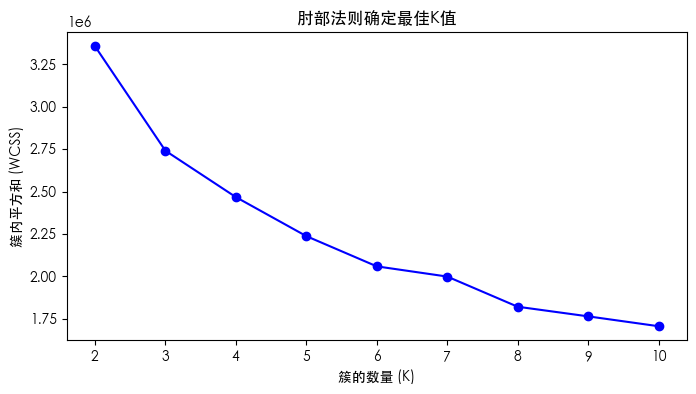

In [8]:
# 肘部法则：计算不同K值下的簇内平方和 (WCSS)
wcss = []
k_range = range(2, 11) # 尝试 2 到 10 个簇

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_) # inertia_ 即 WCSS

# 绘制肘部图
plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, 'bo-')
plt.xlabel('簇的数量 (K)')
plt.ylabel('簇内平方和 (WCSS)')
plt.title('肘部法则确定最佳K值')
plt.show()

In [9]:
# 3. 训练最终模型
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X)

user_features['cluster'] = cluster_labels
if 'user_id' in user_features_scaled.columns and len(user_features_scaled) == len(user_features):
    user_features_scaled['cluster'] = cluster_labels
else:
    user_features_scaled = user_features_scaled.merge(user_features[['user_id', 'cluster']], on='user_id', how='left')

# 保存带群组标签的数据
user_features.to_parquet('data/parquet/user_features_raw_with_cluster.parquet', index=False)
user_features_scaled.to_parquet('data/parquet/user_features_scaled_with_cluster.parquet', index=False)
order.to_parquet('data/parquet/user_order_cleaned.parquet', index=False)
print('已保存 user_features_raw_with_cluster.parquet、user_features_scaled_with_cluster.parquet 和 user_order_cleaned.parquet')

已保存 user_features_raw_with_cluster.parquet、user_features_scaled_with_cluster.parquet 和 user_order_cleaned.parquet


In [10]:
# 滑动窗口特征（用于预测任务）
# 定义时间窗口参数
max_date = order['datetime'].dt.date.max()
last_week_start = max_date - pd.Timedelta(days=6)
observation_end = last_week_start - pd.Timedelta(days=1)
observation_start = observation_end - pd.Timedelta(days=29)

# 滑动窗口订单特征
order_obs = order[(order['datetime'].dt.date >= observation_start) & (order['datetime'].dt.date <= observation_end)].copy()
order_window_agg = order_obs.groupby('user_id').agg(
    obs_order_cnt=('datetime', 'count'),
    obs_total_qty=('count', 'sum'),
    obs_unique_items=('item_id', 'nunique'),
    obs_active_days=('datetime', 'nunique'),
).reset_index()

# 滑动窗口点击特征
click_obs = click_filtered[(click_filtered['datetime'].dt.date >= observation_start) & (click_filtered['datetime'].dt.date <= observation_end)].copy()
click_window_agg = click_obs.groupby('user_id').agg(
    obs_click_cnt=('datetime', 'count'),
    obs_unique_click_items=('item_id', 'nunique'),
).reset_index()

# 合并滑动窗口特征
user_features_window = user_features.merge(order_window_agg, on='user_id', how='left').merge(click_window_agg, on='user_id', how='left')
user_features_window.fillna(0, inplace=True)

# 保存滑动窗口特征
user_features_window.to_parquet('data/parquet/user_features_window.parquet', index=False)
print('已保存滑动窗口特征: user_features_window.parquet')

已保存滑动窗口特征: user_features_window.parquet


In [11]:
# 1. 查看各群组样本量
print(user_features['cluster'].value_counts().sort_index())

# 2. 计算各群组的核心特征均值（用于画像）
# 选取关键业务指标：R(最近购买天数), F(购买频次), M(消费金额), 点击活跃度
cluster_profile = user_features.groupby('cluster').agg({
    'R_days': 'mean', # 越小代表越活跃
    'F_count': 'mean',
    'total_order_amount': 'mean',
    'total_clicks': 'mean',
    'has_order': 'mean' # 转化率
}).round(2)

print(cluster_profile)

cluster
0    15553
1    26115
2    40032
3    18300
Name: count, dtype: int64
         R_days  F_count  total_order_amount  total_clicks  has_order
cluster                                                              
0        364.89     0.00                0.06          0.10       0.00
1         30.27    74.00            11646.61       1545.28       1.00
2        102.22     7.60             1923.12        240.00       1.00
3        362.82     0.02                0.12         63.90       0.01


| 聚类标签 | 关键特征描述 | 业务角色定义 | 人群占比 |
| :--- | :--- | :--- | :--- |
| Cluster 2 | R很近 (29天)<br>F极高 (75次)<br>M极高 (1.2万)<br>点击极高 (1568次) | 核心高价值用户<br>忠诚度高、消费能力强、活跃 | ~25% |
| Cluster 0 | R一般 (101天)<br>F中等 (7.8次)<br>M中等 (1963元)<br>点击中等 (243次) | 主力中坚用户<br>有购买习惯，但近期活跃度有所下降 | ~41% |
| Cluster 1 | R很远 (363天)<br>F几乎为0<br>M几乎为0<br>点击低 (63次) | 流失/沉睡用户<br>曾经可能浏览过，但长期未购买，几乎流失 | ~18% |
| Cluster 3 | R很远 (364天)<br>F为0<br>M为0<br>点击几乎为0 | 极低价值/新用户<br>几乎无互动，可能是注册后从未活跃的“僵尸号” | ~16% |



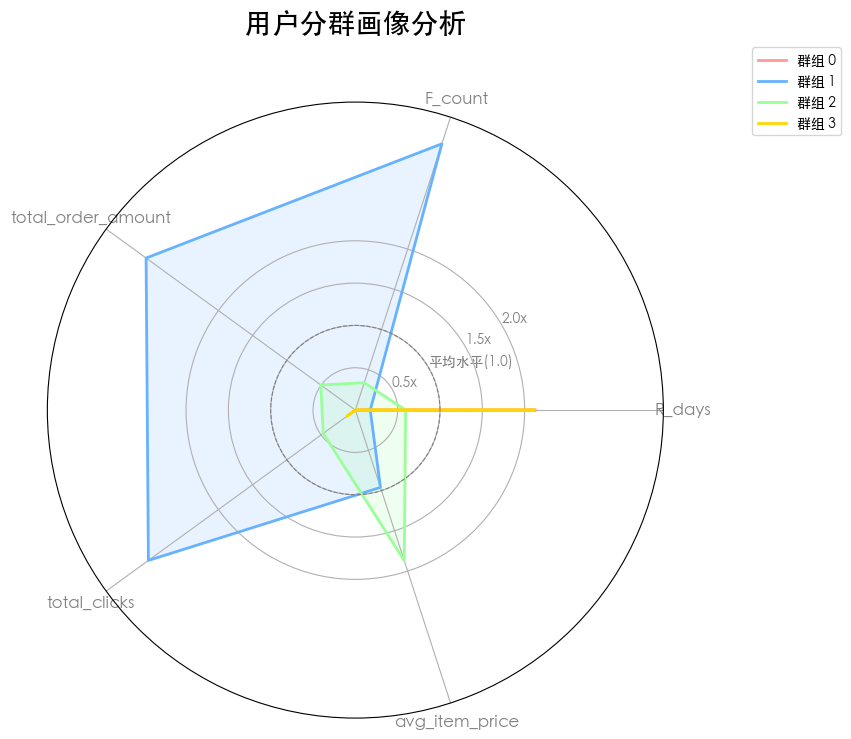

In [12]:
from sklearn.preprocessing import MinMaxScaler

viz_features = ['R_days', 'F_count', 'total_order_amount', 'total_clicks', 'avg_item_price']

# 1. 计算全体用户的平均值（作为基准线）
global_mean = user_features[viz_features].mean()

# 2. 计算各群组的平均值
group_means = user_features.groupby('cluster')[viz_features].mean()
radar_data = group_means.divide(global_mean)

def plot_radar_optimized(data, title):
    categories = list(data.columns)
    N = len(categories)

    # 设置极坐标系
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # 闭合图形

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # 定义颜色
    colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFD700']
    clusters = data.index

    # 绘制每一个群组
    for i, cluster in enumerate(clusters):
        values = data.loc[cluster].values.flatten().tolist()
        values += values[:1]  # 闭合数据
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'群组 {cluster}', color=colors[i])
        ax.fill(angles, values, color=colors[i], alpha=0.15)

    plt.xticks(angles[:-1], categories, color='grey', size=12)
    ax.set_rlabel_position(30)

    # 设置径向刻度（以 1.0 为中心基准）
    max_val = data.values.max() * 1.1
    plt.yticks([0.5, 1.0, 1.5, 2.0], ["0.5x", "平均水平(1.0)", "1.5x", "2.0x"], color="grey", size=10)
    plt.ylim(0, max(2.0, max_val))

    ax.axhline(y=1.0, color='gray', linewidth=0.8, linestyle='--')

    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.title(title, size=20, color='black', y=1.1)
    plt.show()

plot_radar_optimized(radar_data, "用户分群画像分析")